# Trying to guess parameters

### Importing packages

In [ ]:
import numpy as np, matplotlib.pyplot as plt, statsmodels.api as sm

### Inputs

In [ ]:
N = 1_000_000
P = [[0.98, 0.02], [0.05, 0.95]]

mu = [0.0, 0.0]
phi = [0.9, 0.2]
sig = [0.1, 1.5] 

### Generating data

In [25]:
s, y = [0], [0.]

for t in range(1, N+1):
    s.append(np.random.choice([0, 1], p=P[s[-1]]))
    y.append(mu[s[-1]] + phi[s[-1]] * y[-1] + np.random.normal(0, sig[s[-1]]))

y_train, y_test = np.array(y[:-1]), y[-1]

### Plotting

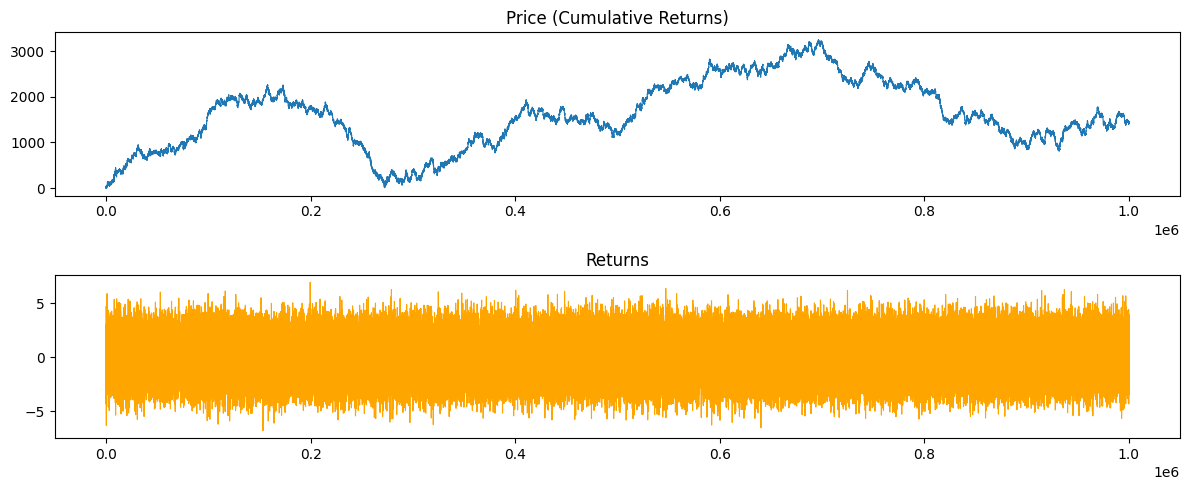

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(211)
plt.plot(np.cumsum(y_train), lw=0.8)
plt.title("Price (Cumulative Returns)")

plt.subplot(212)
plt.plot(y_train, lw=0.2, color='orange')
plt.title("Returns")

plt.tight_layout()
plt.show()

### AR(1)

In [ ]:
ar = sm.tsa.AutoReg(y_train, 1).fit()
ar_mu = ar.predict(start=N, end=N)[0]
ar_var = ar.sigma2

print(f"ar : {ar}\nar_mu : {ar_mu:.6f}\nar_var : {ar_var:.6f}")

ar : <statsmodels.tsa.ar_model.AutoRegResultsWrapper object at 0x7b49c8835d30>
ar_mu : 0.37551282707281575
ar_var : 0.7220632804230301


### MS-AR

In [ ]:
ms = sm.tsa.MarkovAutoregression(y_train, k_regimes=2, order=1, switching_variance=True).fit(disp=False)

# Force everything to flat numpy arrays
# regime_transition is (k, k, 1) in recent statsmodels; squeeze to (k, k) for matmul
trans = np.asarray(ms.regime_transition).squeeze()
filt = np.asarray(ms.filtered_marginal_probabilities)[-1].flatten() # Shape (2,)
params = np.asarray(ms.params)

# 1. Predict next state probabilities
p_next = trans @ filt

# 2. Extract params (Regime 0 then Regime 1)
# Standard MS-AR param order: [p0->0, p1->0, const.0, const.1, ar.L1.0, ar.L1.1, sigma2.0, sigma2.1]
c = params[2:4]
a = params[4:6]
v = params[6:8]

# 3. Forecast Mean and Variance
ms_mu = np.dot(p_next, c + a * y_train[-1])
ms_var = np.dot(p_next, v)

print(f"Pred Mean: {ms_mu:.6f} | Pred Var: {ms_var:.6f}")

### Summary

In [ ]:
def winkler(y, m, v, a=0.05):
    d = 1.96 * np.sqrt(v) 
    l = m-d
    u = m+d
    return (u-l) + 2/a*max(l-y, 0) + 2/a*max(y-u, 0)

print(f"--- PREDICTION ERRORS ---\nAR(1) Winkler: {winkler(y_test, ar_mu, ar_var):.4f}")
print(f"MSAR  Winkler: {winkler(y_test, ms_mu, ms_var):.4f}")
print("\n--- MSAR RECOVERED TRANSITION MATRIX ---")
print(np.asarray(ms.regime_transition).squeeze().round(3))
print("\n--- MODEL SUMMARY ---")
print(ms.summary().tables[1])

--- PREDICTION ERRORS ---
AR(1) Winkler: 3.2680
MSAR  Winkler: 3.6856

--- MSAR RECOVERED TRANSITION MATRIX ---
[[0.981 0.051]
 [0.019 0.949]]

--- MODEL SUMMARY ---
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0080      0.005     -1.606      0.108      -0.018       0.002
sigma2         0.0100   7.59e-05    131.925      0.000       0.010       0.010
ar.L1          0.8992      0.001    826.621      0.000       0.897       0.901
